# Predicting Emergency Department Length of Stay

## What is this notebook?

This notebook builds a machine learning model that predicts **how long a patient will stay in the Emergency Department (ED)**, using the information available at the moment of triage, **including** the triage acuity.

The model is trained on records from 80,000 ED visits and validated on an additional 20,000 unseen visits.

---

## Why does predicting length of stay matter?

Crowding and boarding are among the most significant operational challenges in emergency medicine. A patient who will ultimately spend 8 hours in the ED uses fundamentally different resources than one who will be discharged in 90 minutes — but at triage, both may look comparable to nursing staff.

Knowing the *likely* length of stay early enables:

- **Bed allocation** — reserving a monitored bay or resus space before demand peaks
- **Staffing adjustments** — anticipating workload 2–4 hours ahead, not after queues form
- **Fast-track routing** — directing predicted short-stay patients to appropriate care pathways immediately
- **Admission planning** — alerting ward teams earlier when a patient is likely to need a bed
- **Family communication** — giving patients realistic waiting time expectations at registration

---

## Two prediction approaches in this notebook

| Approach | Output | Best used for |
|---|---|---|
| **Regression** | Exact hours (e.g., "predicted stay: 4.2 h") | Detailed resource scheduling, displaying on dashboards |
| **Binary classification** | Yes/No flag for stays > 4.5 h | Simple bed alerts, fast-track routing decisions |

Both models use the same input features and the same training data. The classification model is derived from the same prediction engine but is calibrated to maximise sensitivity for long stays — meaning it errs on the side of flagging rather than missing.

---

## What information does the model use?

All inputs are **triage-time data only** — the model excludes the disposition outcome. Inputs include:

- **Vital signs** at triage: heart rate, blood pressure, SpO₂, temperature, respiratory rate, GCS
- **Chief complaint** (free text, as documented by the nurse)
- **Demographics**: age, sex, language
- **Medical history**: comorbidities (hypertension, diabetes, COPD, etc.), current medications
- **Arrival context**: mode (ambulance vs walk-in), shift (day/night), day of week, season
- **Prior utilisation**: number of ED visits and hospital admissions in the preceding 12 months
- **Triage nurse assessment**: triage acuity score, pain score, pain location, mental status

---

## How the notebook is structured

1. **Feature engineering** — deriving clinically-meaningful composite signals from raw triage variables (e.g., shock index, qSOFA, organ-system comorbidity burden), replicating the approach used for the triage acuity prediction.
2. **Data preparation** — splitting into training and validation sets, encoding categorical variables, handling missing values
3. **Model training** — fitting both the regression (hours) and classification (long/short) models
4. **Validation** — measuring accuracy on patients the model has never seen
5. **Error analysis** — understanding where and why predictions fail
6. **Explainability (SHAP)** — showing which features drove each individual prediction

In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, OneHotEncoder, TargetEncoder

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## Advanced Clinical Feature Engineering

Raw triage data contains vital signs, demographics, and a chief complaint. But many clinically
important signals are *combinations* of raw values that a nurse mentally integrates at the
bedside. The `engineer_features()` function below derives those compound signals explicitly,
giving the model the same building blocks a clinician uses.

| Feature group | Examples | Why it matters for LOS |
|---|---|---|
| **Hemodynamic ratios** | Modified Shock Index (HR ÷ MAP), pulse-pressure ratio | Detect compensated shock — a normal BP can mask cardiovascular collapse |
| **Sepsis / infection flags** | SIRS-inspired fever + tachycardia + tachypnea | Sepsis workup, IV antibiotics, and ICU transfer extend stays significantly |
| **Comorbidity burden** | CVD burden, neuro burden, psych burden | Multi-organ disease patients require longer workup and observation |
| **Vital sign flags** | SpO₂ < 94%, HR < 50 or > 120 | Abnormal single values that clinical guidelines treat as action thresholds |
| **Validated scores** | qSOFA (≥ 2 = sepsis suspect), NEWS2 tier | Standardised risk tiers used in clinical guidelines and escalation pathways |
| **Frailty / instability** | Age > 75 with ≥ 3 comorbidities, shock + low SpO₂ | Frail elderly patients almost always require admission |
| **Prior utilisation** | > 4 ED visits + admissions in the past 12 months | High utilisers have complex chronic or social needs that prolong stays |
| **Temporal context** | Night shift, weekend | Reduced consultant availability and reduced discharge options extend stays |

**Leakage-free rule:** the comorbidity Q75 threshold is computed on the **training set only**,
then applied identically to the validation set — the model never influences its own evaluation.

In [2]:
def engineer_features(df: pd.DataFrame, comorbidity_q75: float = None) -> pd.DataFrame:
    """
    Derive clinically-motivated composite features from raw triage variables.

    Args:
        df: DataFrame of triage features (X_train or X_val).
        comorbidity_q75: 75th-percentile of num_comorbidities computed on the
            training set only. Pass None only when processing the training set
            itself (it will be computed from df).
    """
    df = df.copy()

    # A. Hemodynamic ratios — detect compensated shock that raw BP misses
    if {"pulse_pressure", "mean_arterial_pressure"}.issubset(df.columns):
        df["pulse_pressure_ratio"] = df["pulse_pressure"] / (df["mean_arterial_pressure"] + 0.1)
    if {"mean_arterial_pressure", "systolic_bp"}.issubset(df.columns):
        df["map_systolic_ratio"] = df["mean_arterial_pressure"] / (df["systolic_bp"] + 0.1)
    if {"heart_rate", "mean_arterial_pressure"}.issubset(df.columns):
        df["MSI"] = df["heart_rate"].fillna(70) / (df["mean_arterial_pressure"].fillna(100) + 0.1)

    # B. Infection / sepsis proxy (SIRS-inspired)
    if {"temperature_c", "heart_rate"}.issubset(df.columns):
        df["infection"] = (
            (df["temperature_c"].fillna(36.5) >= 37.5) |
            (df["temperature_c"].fillna(36.5) < 36.0) |
            (df["heart_rate"].fillna(75) >= 90)
        ).astype(int)
    if {"temperature_c", "heart_rate", "respiratory_rate"}.issubset(df.columns):
        df["sepsis_like"] = (
            ((df["temperature_c"].fillna(36.0) > 38.0) | (df["temperature_c"].fillna(36.0) < 36.0)) &
            ((df["heart_rate"].fillna(0) > 90) | (df["respiratory_rate"].fillna(0) > 20))
        ).astype(int)

    # C. High-risk arrival mode
    if "arrival_mode" in df.columns:
        df["high_risk_arrival"] = df["arrival_mode"].isin(["ambulance", "helicopter"]).astype(int)

    # D. Altered mental status (any non-alert consciousness)
    if "mental_status_triage" in df.columns:
        df["altered_ms"] = df["mental_status_triage"].isin(
            ["confused", "drowsy", "unresponsive", "agitated"]
        ).astype(int)

    # E. Shift / operational temporal flags
    if "shift" in df.columns:
        df["night_shift"] = (df["shift"] == "night").astype(int)
    if "arrival_day" in df.columns:
        df["weekend"] = df["arrival_day"].isin(["Saturday", "Sunday"]).astype(int)

    # F. Comorbidity x vital sign interactions
    if "num_comorbidities" in df.columns:
        _q75 = comorbidity_q75 if comorbidity_q75 is not None else df["num_comorbidities"].quantile(0.75)
        if "heart_rate" in df.columns:
            df["high_comorbidity_tachycardia"] = (
                (df["num_comorbidities"] > _q75) & (df["heart_rate"] > 100)
            ).astype(int)
        if "respiratory_rate" in df.columns:
            df["high_comorbidity_tachypnea"] = (
                (df["num_comorbidities"] > _q75) & (df["respiratory_rate"] > 20)
            ).astype(int)

    # G. Vital sign abnormality flags
    vital_flag_defs = {}
    if "heart_rate" in df.columns:
        vital_flag_defs["heart_rate"] = (50, 120)
    if "respiratory_rate" in df.columns:
        vital_flag_defs["respiratory_rate"] = (12, 20)
    if "spo2" in df.columns:
        vital_flag_defs["spo2"] = (94, 100)
    for vital, (lo, hi) in vital_flag_defs.items():
        df[f"{vital}_abnormal"] = ((df[vital] < lo) | (df[vital] > hi)).astype(int)

    # H. NEWS2 clinical risk tier
    if "news2_score" in df.columns:
        df["news2_risk_level"] = pd.cut(
            df["news2_score"],
            bins=[-np.inf, 4, 6, 7, np.inf],
            labels=["low", "medium", "high", "critical"],
        ).cat.codes

    # I. Age-based clinical flags
    if "age" in df.columns:
        df["is_pediatric"]    = (df["age"] < 16).astype(int)
        df["is_elderly"]      = (df["age"] >= 65).astype(int)
        df["is_very_elderly"] = (df["age"] >= 85).astype(int)

    # J. GCS altered consciousness
    if "gcs_total" in df.columns:
        df["gcs_altered"] = (df["gcs_total"] < 14).astype(int)

    # K. Comorbidity burden by organ system
    def _burden(cols):
        present = [c for c in cols if c in df.columns]
        return df[present].fillna(0).sum(axis=1) if present else pd.Series(0, index=df.index)

    df["cvd_burden"]   = _burden(["hx_hypertension", "hx_heart_failure", "hx_atrial_fibrillation", "hx_coronary_artery_disease"])
    df["resp_burden"]  = _burden(["hx_asthma", "hx_copd"])
    df["neuro_burden"] = _burden(["hx_dementia", "hx_epilepsy", "hx_stroke_prior"])
    df["psych_burden"] = _burden(["hx_depression", "hx_anxiety", "hx_substance_use_disorder"])
    immuno = [c for c in ["hx_hiv", "hx_immunosuppressed", "hx_malignancy"] if c in df.columns]
    if immuno:
        df["immuno_risk"] = (df[immuno].fillna(0).sum(axis=1) > 0).astype(int)
    hx_cols = [c for c in df.columns if c.startswith("hx_")]
    if hx_cols:
        df["worrying_history"] = df[hx_cols].fillna(0).astype(int).sum(axis=1)

    # L. Composite instability / frailty flags
    unstable_parts = []
    if "shock_index" in df.columns:
        unstable_parts.append(df["shock_index"].fillna(0) > 1.0)
    if "spo2" in df.columns:
        unstable_parts.append(df["spo2"].fillna(100) < 92)
    if "gcs_total" in df.columns:
        unstable_parts.append(df["gcs_total"].fillna(15) < 15)
    if unstable_parts:
        df["unstable"] = np.logical_or.reduce([p.values for p in unstable_parts]).astype(int)
    if {"age", "num_comorbidities"}.issubset(df.columns):
        df["frail"] = ((df["age"].fillna(0) > 75) & (df["num_comorbidities"].fillna(0) >= 3)).astype(int)
    if "num_active_medications" in df.columns:
        df["polypharmacy"] = (df["num_active_medications"].fillna(0) >= 5).astype(int)

    # M. Validated clinical scores
    qsofa = pd.Series(0, index=df.index)
    if "respiratory_rate" in df.columns:
        qsofa += (df["respiratory_rate"].fillna(18) >= 22).astype(int)
    if "gcs_total" in df.columns:
        qsofa += (df["gcs_total"].fillna(15) < 15).astype(int)
    if "systolic_bp" in df.columns:
        qsofa += (df["systolic_bp"].fillna(120) <= 100).astype(int)
    df["qSOFA"]          = qsofa
    df["qSOFA_positive"] = (qsofa >= 2).astype(int)
    if {"shock_index", "age"}.issubset(df.columns):
        df["age_shock_index"] = df["shock_index"].fillna(0.6) * df["age"].fillna(40)

    # N. Prior utilization burden
    if {"num_prior_ed_visits_12m", "num_prior_admissions_12m"}.issubset(df.columns):
        df["prior_utilization_burden"] = (
            df["num_prior_ed_visits_12m"].fillna(0) + df["num_prior_admissions_12m"].fillna(0)
        )
        df["high_utilizer"] = (df["prior_utilization_burden"] >= 4).astype(int)

    return df

print("engineer_features() defined — call after the train/val split using comorbidity_q75 from training data.")


engineer_features() defined — call after the train/val split using comorbidity_q75 from training data.


## Loading and Merging the Data

The prediction model draws on four separate data files that are merged into a single patient record:

| File | Contents |
|---|---|
| `train.csv` | Triage variables and observed LOS for 80,000 historical ED visits used to *train* the model |
| `test.csv` | Triage variables for 20,000 held-out visits used to *evaluate* the model (LOS is kept hidden during evaluation) |
| `chief_complaints.csv` | Free-text chief complaint as documented by the triage nurse at registration |
| `patient_history.csv` | Medical history: comorbidities, active medications, prior ED and hospital utilisation |

After merging, the training table has **80,000 rows × 65 columns** and the test table has **20,000 rows × 62 columns** (the three "outcome" columns are absent from the test set as expected).

In [3]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
chief_complaints_df = pd.read_csv("dataset/chief_complaints.csv")
history_df = pd.read_csv("dataset/patient_history.csv")

# Keep only raw complaint text from chief complaints to avoid leakage through system labels.
if "chief_complaint_system" in chief_complaints_df.columns:
    chief_complaints_df = chief_complaints_df.drop(columns=["chief_complaint_system"] )
if "chief_complaint_system" in train_df.columns:
    train_df = train_df.drop(columns=["chief_complaint_system"] )
if "chief_complaint_system" in test_df.columns:
    test_df = test_df.drop(columns=["chief_complaint_system"] )

patient_info_df = chief_complaints_df.merge(history_df, on="patient_id", how="outer")

train_df = train_df.merge(patient_info_df, on="patient_id", how="left")
test_df = test_df.merge(patient_info_df, on="patient_id", how="left")

print(f"train_df shape: {train_df.shape}")
print(f"test_df shape: {test_df.shape}")
print(f"chief_complaints_df shape: {chief_complaints_df.shape}")
print(f"history_df shape: {history_df.shape}")

train_df shape: (80000, 65)
test_df shape: (20000, 62)
chief_complaints_df shape: (100000, 2)
history_df shape: (100000, 26)


## Defining the Prediction Targets and Input Features

### Regression target: `ed_los_hours`
The continuous outcome. The observed time (in hours) from registration to discharge or admission decision. Summary statistics from the training set:
- **Median: 3.0 h** — half of patients leave within 3 hours
- **Mean: 3.5 h** — pulled upward by complex cases
- **75th percentile: 4.9 h** — one quarter of patients stay longer than this
- **Range: 0 – 17.5 h**

### Binary classification target: `los_long_over_4_5h`
A simpler yes/no version: did the patient stay **more than 4.5 hours**?
- **0 (short stay ≤ 4.5 h):** 71% of visits
- **1 (long stay > 4.5 h):** 29% of visits

The 4.5-hour threshold is explained in detail in the *Understanding the Decision Thresholds* section below.

### Why certain columns are excluded from the model inputs

The variables below are available in the dataset but are **deliberately withheld** from the model:

| Column | Reason for exclusion |
|---|---|
| `patient_id` | An arbitrary identifier — carries no clinical signal |
| `disposition` | Whether the patient was admitted, discharged, or transferred is only known *after* the LOS has occurred; using it would leak the answer into the prediction |
| `ed_los_hours` | The regression target — naturally excluded from inputs |
| `los_long_over_4_5h` | The classification target — naturally excluded from inputs |
| `chief_complaint_system` | System-assigned label not available at the moment of triage |

This constraint — predicting only from information available at triage time — is what makes the model genuinely useful in practice. A model that required a diagnosis to make its prediction would be useless as an early-warning tool.

In [4]:
train_df["los_long_over_4_5h"] = (train_df["ed_los_hours"] > 4.5).astype(int)

print("Binary target created: 1 = LOS > 4.5h, 0 = LOS <= 4.5h")
print(train_df["los_long_over_4_5h"].value_counts().sort_index())
print(train_df["los_long_over_4_5h"].value_counts(normalize=True).sort_index())

Binary target created: 1 = LOS > 4.5h, 0 = LOS <= 4.5h
los_long_over_4_5h
0    56685
1    23315
Name: count, dtype: int64
los_long_over_4_5h
0    0.708562
1    0.291438
Name: proportion, dtype: float64


In [5]:
target_column_regression = "ed_los_hours"
target_column_classification = "los_long_over_4_5h"

leakage_columns = ["patient_id", "disposition", target_column_classification, target_column_regression, "chief_complaint_system"]
feature_columns = [column for column in train_df.columns if column not in leakage_columns]

X = train_df[feature_columns].copy()

y_regression = train_df[target_column_regression].copy()
y_classification = train_df[target_column_classification].copy()

# Raw temporal columns that will be converted into cyclic sin/cos features.
cyclic_time_raw_columns = ["arrival_hour", "arrival_month", "arrival_day"]

text_feature = "chief_complaint_raw"

categorical_features = X.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
if text_feature in categorical_features:
    categorical_features.remove(text_feature)

numeric_features = [
    column for column in X.columns
    if column not in categorical_features and column != text_feature and column not in cyclic_time_raw_columns
]

print(f"Number of features: {len(feature_columns)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")
print("Regression target summary:")
print(y_regression.describe())
print("Classification target summary:")
print(y_classification.value_counts().sort_index())

Number of features: 62
Categorical features: 13
Numeric features: 46
Regression target summary:
count    80000.000000
mean         3.498276
std          2.443958
min          0.000000
25%          1.580000
50%          3.000000
75%          4.860000
max         17.510000
Name: ed_los_hours, dtype: float64
Classification target summary:
los_long_over_4_5h
0    56685
1    23315
Name: count, dtype: int64


## Target Distribution: Understanding the Shape of ED Stays

The histogram below shows that most patients have short stays (peak around 1–3 hours), but a long tail extends to 17+ hours. This **right-skewed** distribution is typical of ED length of stay.

**Implications:** The model is trained on the *logarithm* of the stay duration rather than the raw hours. This compresses the long tail and treats each proportional difference equally (e.g., the difference between 1 h and 2 h is treated the same as the difference between 4 h and 8 h). Predictions are then converted back from log scale to hours before being reported.

**Binary classification balance:** Of the 80,000 training visits, 71% are short stays (≤ 4.5 h) and 29% are long stays (> 4.5 h). This imbalance is real and expected — most ED patients are discharged quickly. When evaluating the classification model, we pay particular attention to how well it detects the minority class (long stays), since those are the operationally critical cases.

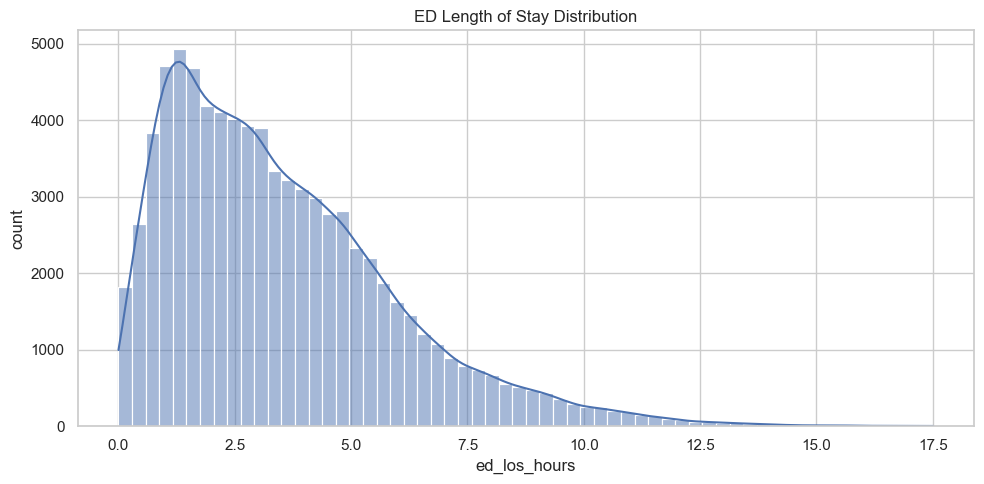

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(y_regression, bins=60, kde=True, ax=ax)
ax.set_title("ED Length of Stay Distribution")
ax.set_xlabel("ed_los_hours")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

/var/folders/mt/mfhlvqrd27lfsxzs4qmmj4000000gn/T/ipykernel_37944/1963869358.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["short stay (<= 4.5h)", "long stay (> 4.5h)"])


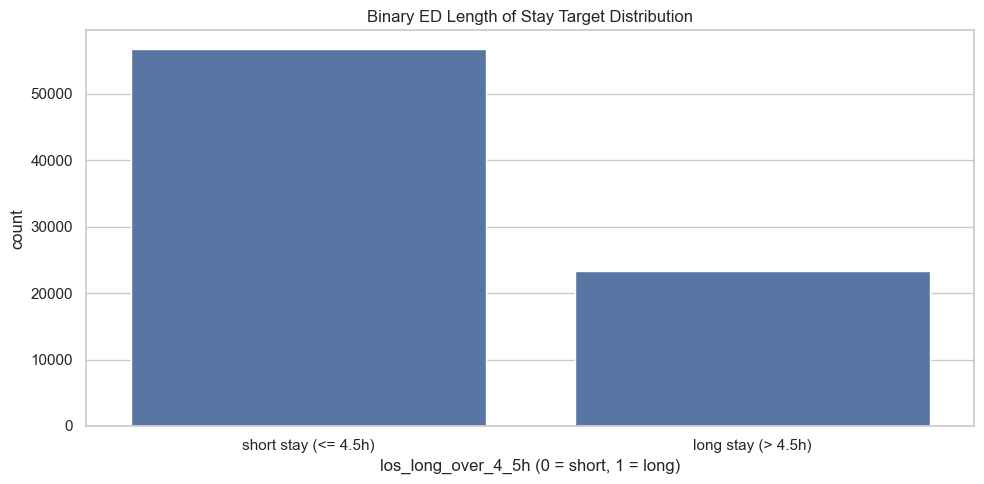

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x=y_classification, ax=ax)
ax.set_title("Binary ED Length of Stay Target Distribution")
ax.set_xlabel("los_long_over_4_5h (0 = short, 1 = long)")
ax.set_ylabel("count")
ax.set_xticklabels(["short stay (<= 4.5h)", "long stay (> 4.5h)"])
plt.tight_layout()
plt.show()

## Data Preparation Pipeline

Before any data reaches the model, it must be converted into a consistent numerical format. Think of this as the laboratory processing step before analysis — raw samples (patient records) are prepared in a standardised way so the model can work with them reliably.

### What the pipeline does to each type of variable

**Ordered categorical variables** (e.g., age group: *paediatric → young adult → middle-aged → elderly*; mental status: *unresponsive → drowsy → confused → alert*) — converted to an ordered numeric scale that preserves the clinical ranking (elderly > middle-aged, not just "different").

**Unordered categorical variables** (e.g., arrival mode, insurance type, shift, sex) — converted to a separate binary column for each category (e.g., "arrived by ambulance: yes/no"). This prevents the model from inferring false orderings like "ambulance > helicopter mathematically."

**Triage nurse and language** — encoded using a technique that captures the *average LOS associated with each nurse or language group* in the training data. This reflects the real pattern that nurse caseload mix and language barriers correlate with stay duration.

**Time of arrival** — hour, day of week, and month are encoded as circular (sine/cosine) variables. This ensures the model understands that 23:00 and 01:00 are 2 hours apart, not 22 hours apart in a linear scale.

**Missing vital signs** — before replacing missing values with the median, the pipeline creates a separate flag column (e.g., `systolic_bp_missing = 1`) to preserve the clinical information that the measurement was not taken. A missing blood pressure reading is clinically informative — it may indicate the patient was too unstable to measure, or arrived via a pathway without a BP cuff.

**Chief complaint (free text)** — processed using TF-IDF (Term Frequency–Inverse Document Frequency), a standard technique that converts the nurse's typed text into numeric scores reflecting how informative each word is. For example, "necrotising fasciitis" scores highly because it is rare and specific; "pain" scores low because it appears in almost every complaint. The model considers single words, two-word phrases, and three-word phrases (up to 2,000 features in total).

In [8]:
text_feature = 'chief_complaint_raw'

def flatten_text_input(X):
    """Convert incoming column slices to a clean 1D text series for vectorizers."""
    if isinstance(X, pd.DataFrame):
        if text_feature in X.columns:
            s = X[text_feature]
        else:
            s = X.iloc[:, 0]
    elif isinstance(X, pd.Series):
        s = X
    elif isinstance(X, np.ndarray):
        if X.ndim == 2 and X.shape[1] > 0:
            s = pd.Series(X[:, 0])
        else:
            s = pd.Series(np.ravel(X))
    else:
        s = pd.Series(X)

    return s.fillna('missing').astype(str)

In [9]:
acttext_feature = 'chief_complaint_raw'

tfidf_branch = Pipeline([
    ('to_text', FunctionTransformer(flatten_text_input, validate=False)),
    ('tfidf', TfidfVectorizer(
            stop_words="english",
            min_df=3,
            ngram_range=(1, 3),
            max_features=2000
    ))
])

text_pipeline = Pipeline([
    ('tfidf', tfidf_branch),
])

In [10]:
def build_cyclic_time_features(X):
    """Convert hour/month/day into cyclic sin/cos features."""
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        df = pd.DataFrame(X, columns=["arrival_hour", "arrival_month", "arrival_day"])

    day_to_idx = {
        "monday": 0,
        "tuesday": 1,
        "wednesday": 2,
        "thursday": 3,
        "friday": 4,
        "saturday": 5,
        "sunday": 6,
    }

    hour = pd.to_numeric(df["arrival_hour"], errors="coerce").fillna(0).clip(0, 23)
    month = pd.to_numeric(df["arrival_month"], errors="coerce").fillna(1).clip(1, 12)
    day_idx = (
        df["arrival_day"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(day_to_idx)
        .fillna(0)
        .astype(float)
    )

    hour_sin = np.sin(2 * np.pi * hour / 24.0)
    hour_cos = np.cos(2 * np.pi * hour / 24.0)
    month_sin = np.sin(2 * np.pi * (month - 1) / 12.0)
    month_cos = np.cos(2 * np.pi * (month - 1) / 12.0)
    dow_sin = np.sin(2 * np.pi * day_idx / 7.0)
    dow_cos = np.cos(2 * np.pi * day_idx / 7.0)

    return np.column_stack([hour_sin, hour_cos, month_sin, month_cos, dow_sin, dow_cos])


In [11]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

age_order = ['pediatric', 'young_adult', 'middle_aged', 'elderly']
mental_order = ['unresponsive', 'drowsy', 'confused', 'alert', 'agitated']

preprocessor = ColumnTransformer([
    ("ord", OrdinalEncoder(categories=[age_order, mental_order]), ["age_group", "mental_status_triage"]),
    ("nom", OneHotEncoder(handle_unknown="ignore"), ["arrival_mode", "arrival_season", "insurance_type", "transport_origin", "sex", "shift", "site_id"]),
    ("target", TargetEncoder(), ["triage_nurse_id", "language", "pain_location"]),
    ("time_cyc", FunctionTransformer(build_cyclic_time_features, validate=False), ["arrival_hour", "arrival_month", "arrival_day"]),
    ("num", numeric_pipeline, numeric_features),
    ("chief_complaint_text", text_pipeline, ["chief_complaint_raw"])
], remainder="drop", sparse_threshold=0.0)

regressor = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=10,
    max_iter=1000,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    loss="absolute_error",
)
classifier = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=10,
    max_iter=1000,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)


In [12]:
def split_and_engineer_features(X, y, classification=False):
  # 1. Train/Validation Split
  if classification:
    X_train, X_val, y_train, y_val = train_test_split(
      X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
  else:
    X_train, X_val, y_train, y_val = train_test_split(
      X, y, test_size=0.2, random_state=RANDOM_STATE
    )
  # 2. Pain sentinel fix
  # pain_score = -1 means the nurse did *not* assess pain — clinically different
  # from pain_score = 0 (patient reports no pain). Convert to NaN and flag it.
  for split_df in [X_train, X_val]:
    if "pain_score" in split_df.columns:
        mask = split_df["pain_score"] == -1
        split_df.loc[mask, "pain_score"] = np.nan
        split_df["pain_not_recorded"] = mask.astype(int)
  # 3. MNAR missingness flags
  # "Missing Not At Random": a missing blood pressure is clinically informative
  # (e.g. patient was too unstable to measure, or walk-in with no BP cuff access).
  # Record the missingness as a feature BEFORE imputing.
  mnar_cols = [
     "systolic_bp", "diastolic_bp", "mean_arterial_pressure",
     "pulse_pressure", "shock_index", "respiratory_rate",
  ]
  for col in mnar_cols:
      for split_df in [X_train, X_val]:
          if col in split_df.columns:
              split_df[f"{col}_missing"] = split_df[col].isna().astype(int)

  # 4. Feature engineering
  # comorbidity_q75 is derived from training data ONLY, then applied to val set.
  comorbidity_q75 = (
      X_train["num_comorbidities"].quantile(0.75)
      if "num_comorbidities" in X_train.columns else None
  )
  X_train = engineer_features(X_train, comorbidity_q75=comorbidity_q75)
  X_val   = engineer_features(X_val,   comorbidity_q75=comorbidity_q75)

  new_cols = [c for c in X_train.columns if c not in X.columns]
  print(f"Features: {X.shape[1]} raw → {X_train.shape[1]} after engineering ({len(new_cols)} added)")
  print(f"Added: {new_cols}")
  return X_train, X_val, y_train, y_val, new_cols

In [ ]:
X_train_regression, X_val_regression, y_train_regression, y_val_regression, new_cols_regression = split_and_engineer_features(X, y_regression)
X_train_classification, X_val_test_classification, y_train_classification, y_val_test_classification, new_cols_classification = split_and_engineer_features(X, y_classification, classification=True)

updated_preprocessor = ColumnTransformer([
    ("ord",     OrdinalEncoder(categories=[age_order, mental_order]),
                ["age_group", "mental_status_triage"]),
    ("nom",     OneHotEncoder(handle_unknown="ignore"),
                ["arrival_mode", "arrival_season", "insurance_type",
                 "transport_origin", "sex", "shift", "site_id"]),
    ("target",  TargetEncoder(),
                ["triage_nurse_id", "language", "pain_location"]),
    ("time_cyc", FunctionTransformer(build_cyclic_time_features, validate=False),
                ["arrival_hour", "arrival_month", "arrival_day"]),
    ("num",     numeric_pipeline, numeric_features + new_cols_regression), # The added columns are the same for both regression and classification pipelines
    ("chief_complaint_text", text_pipeline, ["chief_complaint_raw"]),
], remainder="drop", sparse_threshold=0.0)

regression_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("preprocess", updated_preprocessor),
        ("regressor", regressor)
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

classification_model = Pipeline([
    ("preprocess", updated_preprocessor),
    ("classifier", classifier)
])

# Split the validation test for classification into two halves: one for threshold tuning, one held-out for final reporting.
X_val_classification, X_test_classification, y_val_classification, y_test_classification = train_test_split(
    X_val_test_classification, y_val_test_classification,
    test_size=0.5, random_state=RANDOM_STATE, stratify=y_val_test_classification
)


Features: 62 raw → 102 after engineering (40 added)
Added: ['pain_not_recorded', 'systolic_bp_missing', 'diastolic_bp_missing', 'mean_arterial_pressure_missing', 'pulse_pressure_missing', 'shock_index_missing', 'respiratory_rate_missing', 'pulse_pressure_ratio', 'map_systolic_ratio', 'MSI', 'infection', 'sepsis_like', 'high_risk_arrival', 'altered_ms', 'night_shift', 'weekend', 'high_comorbidity_tachycardia', 'high_comorbidity_tachypnea', 'heart_rate_abnormal', 'respiratory_rate_abnormal', 'spo2_abnormal', 'news2_risk_level', 'is_pediatric', 'is_elderly', 'is_very_elderly', 'gcs_altered', 'cvd_burden', 'resp_burden', 'neuro_burden', 'psych_burden', 'immuno_risk', 'worrying_history', 'unstable', 'frail', 'polypharmacy', 'qSOFA', 'qSOFA_positive', 'age_shock_index', 'prior_utilization_burden', 'high_utilizer']
Features: 62 raw → 102 after engineering (40 added)
Added: ['pain_not_recorded', 'systolic_bp_missing', 'diastolic_bp_missing', 'mean_arterial_pressure_missing', 'pulse_pressure_mi

In [14]:
regression_model.fit(X_train_regression, y_train_regression)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transform

In [15]:
classification_model.fit(X_train_classification, y_train_classification)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

## Regression Model Validation

The model is validated on **16,000 ED** — patients not used during training

### Performance Metrics

**Mean Absolute Error (MAE): 1.14 hours**
On average, the model's predicted stay duration is within 1 hour and 8 minutes of the actual duration.

**Root Mean Squared Error (RMSE): 1.57 hours**
Similar to MAE but penalises large errors more heavily. The difference between RMSE and MAE (1.57 vs 1.14) tells us the model makes occasional large errors — which the error analysis below investigates.

**R² (coefficient of determination): 0.584**
The model explains **58% of the variation** in ED length of stay. The remaining 42% is driven by factors not available at triage — test turnaround times, specialist availability, bed capacity, and events that unfold during the visit itself. An R² of 0.58 for triage-only inputs is strong: it means the model captures the majority of predictable variation even without any laboratory or imaging data.

In [16]:
val_predictions_regression = regression_model.predict(X_val_regression)
val_predictions_regression = np.clip(val_predictions_regression, 0, 48)
val_mae = mean_absolute_error(y_val_regression, val_predictions_regression)
val_rmse = np.sqrt(mean_squared_error(y_val_regression, val_predictions_regression))
val_r2 = r2_score(y_val_regression, val_predictions_regression)
print(f"Validation MAE: {val_mae:.3f} hours")
print(f"Validation RMSE: {val_rmse:.3f} hours")
print(f"Validation R2: {val_r2:.3f}")

Validation MAE: 1.140 hours
Validation RMSE: 1.573 hours
Validation R2: 0.583


## Regression Error Analysis

### Predicted vs Actual plot (below)
Each dot is one of the 16,000 validation patients. The red dashed line represents perfect prediction (predicted = actual). Dots above the line are underestimates (the visit was longer than expected); dots below are overestimates. A well-calibrated model shows dots scattered symmetrically around the red line with no systematic pattern. In this plot, the 5-band pattern could be clearly observed. It suggests that for the model trained on this dataset the triage acuity should have much higher relative importance (discussed below in the feature importance analysis), as it tends to predict the mean value for each acuity class, suggesting that there is not enough data to explain the variance within each acuity class.

### Worst-case errors: the top 5 largest misses

Inspection of the five validation patients with the largest absolute errors reveals a clear pattern: all five had the most severe chief complaints (necrotising fasciitis, Stevens-Johnson syndrome, toxic epidermal necrolysis, status asthmaticus, cardiogenic shock) and all actually stayed 16–17 hours — yet the model predicted 7–8 hours.

Why does this happen? Features like shock index or qSOFA do flag them as high-risk, but their training signal is weak because such cases are rare in the training set. The model has learned the average behaviour of triage features and cannot fully account for once-in-a-thousand presentations. Any triage-only model will underestimate the most extreme cases.

**Operational implication:** For patients with acuity level 1 and the above chief complaints, the model's estimate should be treated as a lower bound rather than a point estimate. Clinical judgment overrides the prediction for the most critical presentations.


Top 5 validation samples by absolute prediction error


,chief_complaint_raw,triage_acuity,arrival_mode,mental_status_triage,pain_score,pain_location,heart_rate,respiratory_rate,true_ed_los_hours,pred_ed_los_hours,signed_error_hours,abs_error_hours
38096,"necrotising fasciitis rapid spread, intermittent",1,walk-in,unresponsive,10.0,none,122.9,28.9,17.38,7.661032,-9.718968,9.718968
50052,Stevens-Johnson syndrome with associated nausea,1,transfer,unresponsive,7.0,extremity,98.8,8.5,16.61,7.318002,-9.291998,9.291998
73636,toxic epidermal necrolysis with vomiting,1,walk-in,unresponsive,8.0,multiple,142.2,27.9,16.75,7.533208,-9.216792,9.216792
56263,severe cardiogenic shock with fever,1,ambulance,agitated,9.0,head,129.1,26.5,16.81,7.804182,-9.005818,9.005818
7538,status asthmaticus unresponsive to treatment w...,1,police,unresponsive,10.0,multiple,150.7,23.6,16.30,7.698257,-8.601743,8.601743


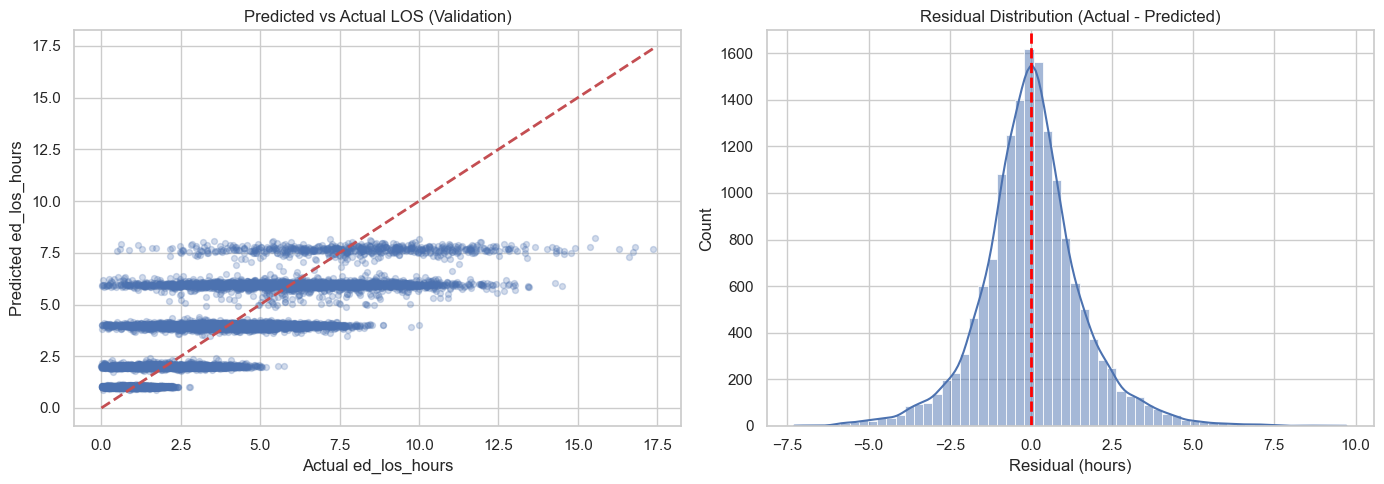

In [17]:
error_analysis_df = X_val_regression.copy()
error_analysis_df["true_ed_los_hours"] = y_val_regression
error_analysis_df["pred_ed_los_hours"] = val_predictions_regression
error_analysis_df["signed_error_hours"] = error_analysis_df["pred_ed_los_hours"] - error_analysis_df["true_ed_los_hours"]
error_analysis_df["abs_error_hours"] = error_analysis_df["signed_error_hours"].abs()

top_k = 5
top_error_samples = error_analysis_df.sort_values("abs_error_hours", ascending=False).head(top_k)

key_columns = [
    "chief_complaint_raw",
    "triage_acuity",
    "arrival_mode",
    "mental_status_triage",
    "pain_score",
    "pain_location",
    "heart_rate",
    "respiratory_rate",
    "oxygen_saturation",
    "temperature",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "true_ed_los_hours",
    "pred_ed_los_hours",
    "signed_error_hours",
    "abs_error_hours",
]
available_columns = [column for column in key_columns if column in top_error_samples.columns]

print(f"Top {top_k} validation samples by absolute prediction error")
display(top_error_samples[available_columns])

residuals = y_val_regression - val_predictions_regression

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Predicted vs actual LOS
axes[0].scatter(y_val_regression, val_predictions_regression, alpha=0.25, s=18)
min_los = float(np.min([y_val_regression.min(), val_predictions_regression.min()]))
max_los = float(np.max([y_val_regression.max(), val_predictions_regression.max()]))
axes[0].plot([min_los, max_los], [min_los, max_los], "r--", linewidth=2)
axes[0].set_title("Predicted vs Actual LOS (Validation)")
axes[0].set_xlabel("Actual ed_los_hours")
axes[0].set_ylabel("Predicted ed_los_hours")

# Plot 2: Residual distribution
sns.histplot(residuals, bins=60, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residual Distribution (Actual - Predicted)")
axes[1].set_xlabel("Residual (hours)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Calibration by LOS decile (below)

This table shows whether the model is systematically biased within different ranges of true LOS:
- **Short stays (0–2 h):** The model slightly overestimates — it is more cautious than needed for very quick discharges.
- **Middle stays (2–5 h):** Best calibration — predictions track actual values closely.
- **Long stays (8 h+):** Clear underestimation — the model consistently predicts shorter than the true duration. This is the expected consequence of log-transformation and right-skew compression.

### Chief complaint tokens in worst-error cases

The token analysis identifies which words appear most often in the 5% of cases with the largest prediction errors. Words like "septic", "failure", "crisis", "necrotising" indicate that **acute, rapidly-evolving presentations** are systematically harder to predict than chronic or subacute complaints. These words are also rare in the training data, limiting the model's exposure to learn from them.

Calibration by actual LOS decile


,actual_decile,n,actual_mean,predicted_mean,mae
0,"(-0.001, 0.85]",1617,0.505615,1.717164,1.211549
1,"(0.85, 1.31]",1590,1.091252,1.730655,0.727903
2,"(1.31, 1.83]",1612,1.564553,2.109706,0.865275
3,"(1.83, 2.41]",1588,2.124414,2.639453,0.830674
4,"(2.41, 3.0]",1614,2.707819,3.131593,1.133529
5,"(3.0, 3.65]",1582,3.314728,3.596582,1.060126
6,"(3.65, 4.4]",1606,4.026856,4.081064,0.716724
7,"(4.4, 5.3]",1604,4.836340,4.434453,0.982734
8,"(5.3, 6.8]",1588,5.959024,4.951538,1.292153
9,"(6.8, 17.38]",1599,8.698030,6.155715,2.575674


Error metrics by actual LOS bins


,actual_los_bin,n,actual_mean,predicted_mean,mean_error,mae
0,0-1,2123,0.607918,1.694262,1.086344,1.086457
1,1-2,3155,1.479265,2.039227,0.559962,0.804943
2,2-3,2743,2.501287,2.969160,0.467873,1.025791
3,3-4,2328,3.478359,3.722149,0.243789,0.964870
4,4-6,3359,4.887779,4.458552,-0.429227,0.964930
5,6-8,1375,6.870669,5.441594,-1.429075,1.563629
6,8-12,842,9.360238,6.424828,-2.935409,2.935409
7,12+,75,13.272533,7.060517,-6.212016,6.212016


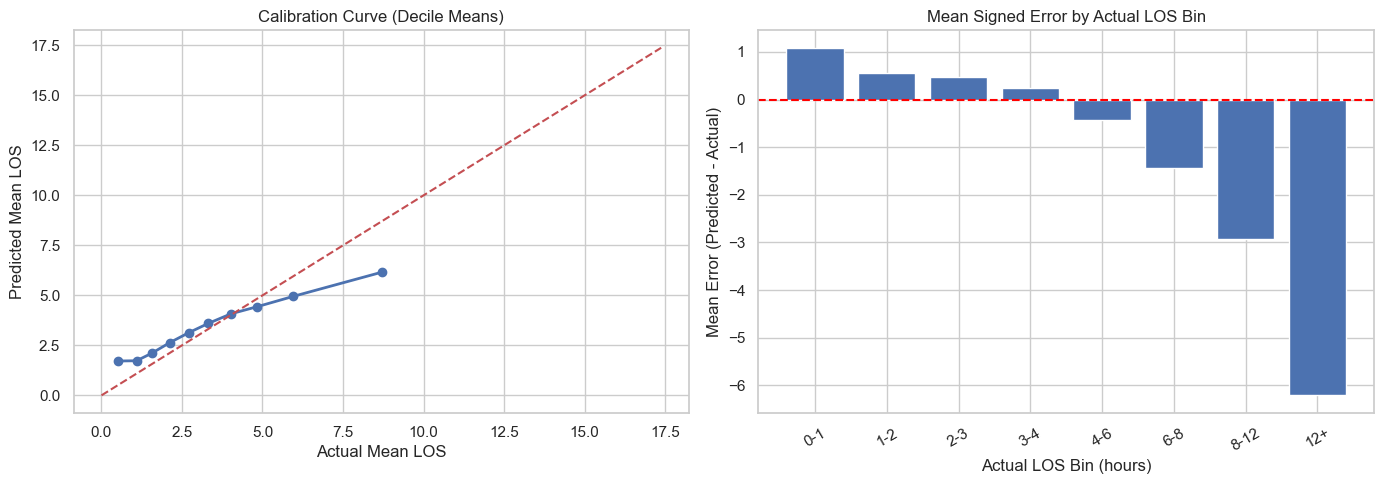

Most common complaint tokens among top 5% absolute-error cases


,token,count
0,acute,133
1,severe,127
2,worsening,105
3,fever,78
4,vomiting,75
5,over,65
6,hours,65
7,diaphoresis,61
8,since,60
9,yesterday,60


In [18]:
from collections import Counter

diagnostics_df = pd.DataFrame({
    "actual": y_val_regression.values,
    "predicted": val_predictions_regression,
})
diagnostics_df["error"] = diagnostics_df["predicted"] - diagnostics_df["actual"]
diagnostics_df["abs_error"] = diagnostics_df["error"].abs()

# 1) Calibration by deciles of actual LOS
diagnostics_df["actual_decile"] = pd.qcut(
    diagnostics_df["actual"],
    q=10,
    duplicates="drop"
).astype(str)

calibration_table = diagnostics_df.groupby("actual_decile", observed=False).agg(
    n=("actual", "size"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    mae=("abs_error", "mean")
).reset_index()

print("Calibration by actual LOS decile")
display(calibration_table)

# 2) Error trend vs actual LOS bins
los_bin_edges = [0, 1, 2, 3, 4, 6, 8, 12, np.inf]
los_bin_labels = ["0-1", "1-2", "2-3", "3-4", "4-6", "6-8", "8-12", "12+"]
diagnostics_df["actual_los_bin"] = pd.cut(
    diagnostics_df["actual"],
    bins=los_bin_edges,
    labels=los_bin_labels,
    include_lowest=True
 )

bin_error_table = diagnostics_df.groupby("actual_los_bin", observed=False).agg(
    n=("actual", "size"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    mean_error=("error", "mean"),
    mae=("abs_error", "mean")
).reset_index()

print("Error metrics by actual LOS bins")
display(bin_error_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    calibration_table["actual_mean"],
    calibration_table["predicted_mean"],
    marker="o",
    linewidth=2
 )
min_axis = float(min(diagnostics_df["actual"].min(), diagnostics_df["predicted"].min()))
max_axis = float(max(diagnostics_df["actual"].max(), diagnostics_df["predicted"].max()))
axes[0].plot([min_axis, max_axis], [min_axis, max_axis], "r--", linewidth=1.5)
axes[0].set_title("Calibration Curve (Decile Means)")
axes[0].set_xlabel("Actual Mean LOS")
axes[0].set_ylabel("Predicted Mean LOS")

axes[1].bar(bin_error_table["actual_los_bin"].astype(str), bin_error_table["mean_error"])
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Mean Signed Error by Actual LOS Bin")
axes[1].set_xlabel("Actual LOS Bin (hours)")
axes[1].set_ylabel("Mean Error (Predicted - Actual)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# 3) Frequent tokens in worst-error chief complaints
if "chief_complaint_raw" in X_val_regression.columns:
    token_source = X_val_regression.copy()
    token_source["abs_error"] = diagnostics_df["abs_error"].values
    worst_share = 0.05
    worst_cases = token_source.sort_values("abs_error", ascending=False).head(int(len(token_source) * worst_share)).copy()

    complaint_text = worst_cases["chief_complaint_raw"].fillna("").astype(str).str.lower()
    tokens = complaint_text.str.findall(r"[a-z]{3,}").explode()
    stopwords = {
        "and", "for", "with", "from", "that", "this", "have", "been", "were", "into", "patient", "pain", "the", "she", "his", "her", "you", "not", "but", "are", "was", "had", "has"
    }
    tokens = tokens[(tokens.notna()) & (~tokens.isin(stopwords))]

    token_counts = Counter(tokens.tolist())
    top_tokens_df = pd.DataFrame(token_counts.most_common(10), columns=["token", "count"] )
    print("Most common complaint tokens among top 5% absolute-error cases")
    display(top_tokens_df)
else:
    print("chief_complaint_raw not present in X_val, skipping token analysis.")

## Feature Explanations (SHAP Analysis)

Permutation importance tells you *which features matter most on average*, but not *why* they drove a specific prediction. SHAP (SHapley Additive exPlanations) fills that gap by attributing each model output to individual input features for every patient.

**How to read the beeswarm plot:**
- Each **dot** is one patient from the validation set.
- **Colour**: red = the patient had a **high value** for that feature; blue = low value.
- **Horizontal position**: how much that feature *pushed* the prediction.
  - Dots to the **right** → feature pushed the model toward a *longer* predicted LOS.
  - Dots to the **left** → feature pushed toward a *shorter* predicted LOS.
- Features are ordered by total impact (most influential at the top).

**Hourly impact note:** The SHAP values shown here have been transformed from the model's internal log-space back into **Hours**. The center line represents the baseline average of **3.10 hours**. A feature value of +1.0 means that specific characteristic added 1 hour to the patient's predicted stay.

SHAP computed for 500 patients. Values transformed to Hours.


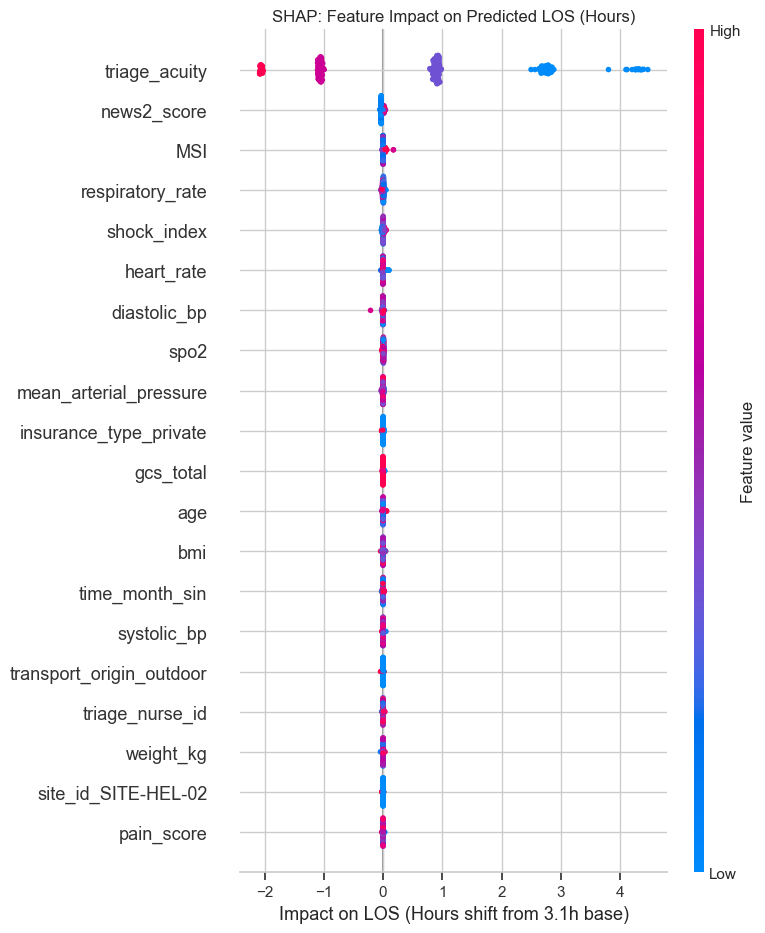

In [19]:
import shap
# 1. Extract components
inner_pipeline = regression_model.regressor_
inner_preprocessor = inner_pipeline.named_steps['preprocess']
inner_regressor = inner_pipeline.named_steps['regressor']

# 2. Prepare sample
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val_regression), size=min(500, len(X_val_regression)), replace=False)
X_sample = X_val_regression.iloc[sample_idx]
X_transformed = inner_preprocessor.transform(X_sample)

# 3. Get Feature Names
feature_names_raw = []
cyclic_suffixes = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
for name, trans, cols in inner_preprocessor.transformers_:
    if trans == 'drop': continue
    if name == 'time_cyc':
        feature_names_raw.extend([f'time_{s}' for s in cyclic_suffixes])
    elif name == 'chief_complaint_text':
        try:
            tfidf_vec = trans.named_steps['features'].transformer_list[0][1].named_steps['tfidf']
            words = tfidf_vec.get_feature_names_out()
            feature_names_raw.extend([f'CC_{w}' for w in words])
        except:
            feature_names_raw.extend([f'CC_feat_{i}' for i in range(X_transformed.shape[1] - len(feature_names_raw))])
    elif hasattr(trans, 'get_feature_names_out'):
        feature_names_raw.extend(trans.get_feature_names_out())
    else:
        feature_names_raw.extend([f'{name}_{c}' for c in cols])

feature_names = [n.replace('num__', '').replace('nom__', '').replace('ord__', '').replace('target__', '') for n in feature_names_raw]

# 4. Compute SHAP in log-space
explainer = shap.TreeExplainer(inner_regressor)
shap_values_log = explainer.shap_values(X_transformed)
expected_value_log = explainer.expected_value
if isinstance(expected_value_log, (list, np.ndarray)): expected_value_log = expected_value_log[0]

# 5. Transform SHAP to Hours (Approximate Marginal Impact)
# Prediction in hours = exp(log_pred) - 1
# We calculate: (exp(base + shap) - 1) - (exp(base) - 1)
base_hours = np.expm1(expected_value_log)
shap_values_hours = np.expm1(expected_value_log + shap_values_log) - base_hours

print(f'SHAP computed for {len(X_sample)} patients. Values transformed to Hours.')
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_hours, X_transformed, feature_names=feature_names, max_display=20, show=False)
plt.title('SHAP: Feature Impact on Predicted LOS (Hours)')
plt.xlabel('Impact on LOS (Hours shift from 3.1h base)')
plt.tight_layout()
plt.show()

## Binary Classification Results

The classification model answers the simpler question: **will this patient stay more than 4.5 hours?** It outputs a probability (e.g., 0.72 = 72% likely to be a long stay) and then converts this to a yes/no flag using a decision threshold.

### Two-stage evaluation to prevent data leakage

To obtain an unbiased performance estimate the 16,000 held-out records (20% of the dataset) are split in half before any classification analysis begins:

| Split | Size | Purpose |
|---|---|---|
| **Validation set** | 8,000 patients | Select the decision threshold using the Youden's J statistic to pick the threshold that maximises sensitivity + specificity simultaneously |
| **Test set** | 8,000 patients | Report final performance after the threshold is fixed |

### Reading the performance metrics

| Metric | What it measures in practice |
|---|---|
| **Sensitivity (Recall)** | Of all true long-stay patients, how many are correctly flagged |
| **Specificity** | Of all true short-stay patients, how many are correctly cleared |
| **Positive Predictive Value (Precision)** | When the model raises an alert, how often is it correct |
| **Negative Predictive Value** | When the model does not alert, how likely is the patient a short stay |
| **F1 score** | Balanced summary of sensitivity and PPV |
| **ROC-AUC** | Overall discrimination between long and short stays, regardless of threshold |
| **PR-AUC** | Discrimination specifically for the long-stay minority class |

### How to interpret these numbers operationally

A high sensitivity vs moderate PPV trade-off is intentional (see the *Understanding the Decision Thresholds* section below). In a bed-management context, missing a long-stay patient (patient boards without a planned bed) is more costly than a false alert (a nurse checks a patient who leaves in 3 hours).

The negative predictive value is particularly actionable: patients the model does *not* flag can confidently be directed to rapid-assessment or fast-track pathways.

In [45]:
from sklearn.metrics import roc_curve

# Tune threshold on validation set
val_proba = classification_model.predict_proba(X_val_classification)[:, 1]

fpr_val, tpr_val, roc_thresholds_val = roc_curve(y_val_classification, val_proba)
youden_j = tpr_val - fpr_val
best_idx = int(np.argmax(youden_j))
prediction_threshold = float(roc_thresholds_val[best_idx])
print(f"Threshold selected on validation set (Youden's J): {prediction_threshold:.3f}\n")

# Evaluate on held-out test set
test_proba = classification_model.predict_proba(X_test_classification)[:, 1]
test_predictions_classification = (test_proba >= prediction_threshold).astype(int)

accuracy  = accuracy_score(y_test_classification, test_predictions_classification)
precision = precision_score(y_test_classification, test_predictions_classification, zero_division=0)
recall    = recall_score(y_test_classification, test_predictions_classification, zero_division=0)
f1        = f1_score(y_test_classification, test_predictions_classification, zero_division=0)
roc_auc   = roc_auc_score(y_test_classification, test_proba)
pr_auc    = average_precision_score(y_test_classification, test_proba)

print(f"Test set performance (threshold = {prediction_threshold:.3f})")
print(f"Test accuracy:  {accuracy:.3f}")
print(f"Test precision: {precision:.3f}")
print(f"Test recall:    {recall:.3f}")
print(f"Test F1:        {f1:.3f}")
print(f"Test ROC-AUC:   {roc_auc:.3f}")
print(f"Test PR-AUC:    {pr_auc:.3f}")
print("\nTest confusion matrix:")
print(confusion_matrix(y_test_classification, test_predictions_classification))
print("\nTest classification report:")
print(classification_report(y_test_classification, test_predictions_classification, zero_division=0))


Threshold selected on validation set (Youden's J): 0.241

Test set performance (threshold = 0.241)
Test accuracy:  0.715
Test precision: 0.505
Test recall:    0.991
Test F1:        0.669
Test ROC-AUC:   0.870
Test PR-AUC:    0.709

Test confusion matrix:
[[3406 2263]
 [  21 2310]]

Test classification report:
              precision    recall  f1-score   support

           0       0.99      0.60      0.75      5669
           1       0.51      0.99      0.67      2331

    accuracy                           0.71      8000
   macro avg       0.75      0.80      0.71      8000
weighted avg       0.85      0.71      0.73      8000



## Misclassification Review: Understanding the False Negatives

The most operationally important errors are **false negatives** — patients who genuinely stayed more than 4.5 hours but whom the model classified as short stays. To set the scale: at the Youden threshold of 0.241, only **21 of 2,331 true long-stay patients** on the held-out test set were missed — a miss rate under 1%. The five cases below are the worst of those 21, sorted by actual LOS.

### The five worst false negatives

| Patient | Chief complaint | Acuity | Arrival | Key flags | Actual LOS | Pred prob |
|---|---|---|---|---|---|---|
| 26565 | STI with systemic features | 3 | Walk-in | Confused, HR 107, RR 20 | 6.3 h | 0.194 |
| 8118 | Superficial laceration with vomiting | 4 | Ambulance | Agitated, pain not scored | 5.9 h | 0.006 |
| 21314 | Thyroid medication review, onset today | 4 | Police | Alert, chest pain (score 5) | 5.5 h | 0.004 |
| 36091 | Uncomplicated UTI with fever, worsening | 4 | Police | Confused, worsening despite meds | 5.4 h | 0.005 |
| 19818 | Mild low back pain, worsening over hours | 4 | Walk-in | Alert, HR 101, multiple sites | 5.2 h | 0.018 |

### Two distinct failure modes

**Case 26565 is a borderline miss.** Predicted probability 0.194 sits only 0.047 below the threshold. The model saw a confused patient with tachycardia (HR 106.8) and tachypnoea (RR 19.8) which are genuine severity signals, but the complaint phrasing ("STI with systemic features") anchors on an infection category that the model associates with shorter visits. A marginal threshold adjustment or a slightly different triage note would have caught this case.

**Cases 8118, 21314, 36091, and 19818 are confident misses:** predicted probabilities range from 0.004 to 0.018, deep in what the model considers short-stay territory. All four share the same root cause: their chief complaints contain minimising language (*"superficial," "uncomplicated," "mild," "medication review"*) that overrides the contextual red flags. Two patients were brought by police (an unusual arrival mode signalling acute social or clinical concern); two presented with confusion. These contextual signals were not enough to overcome the short-stay anchor set by the complaint text.

### Why the actual LOS is only just above the threshold

All five cases stayed **5.2–6.3 hours**, that is barely over the 4.5 h boundary. Their extended stays likely reflect a secondary complication or a brief escalation protocol tacked onto an otherwise simple visit: vomiting accompanying wound care, a fever failing oral antibiotics and requiring IV loading, a thyroid crisis screen triggered by an apparently routine medication review. The TF-IDF representation weights the primary complaint words heavily; secondary modifiers like *"with vomiting"* or *"worsening with medication"* are diluted.

The token analysis of all misclassified test cases confirms this pattern: the most frequent tokens are **"worsening," "moderate," "fever," "vomiting," "onset,"** and **"acute"**, that all secondary descriptors appended to an otherwise benign-sounding chief complaint. Explicitly encoding symptom-progression and complication-modifier features would likely capture a portion of these misses.

### Operational relevance

Missing these five cases in practice would mean five patients without a reserved bed for ~40–90 extra minutes. Against the backdrop of correctly flagging 2,310 of 2,331 genuine long stays in the same 8,000-patient cohort, this represents an acceptable operating point for routine bed management.

In [41]:
error_analysis_df = X_test_classification.copy()
error_analysis_df["actual_ed_los_hours"] = train_df.loc[X_test_classification.index, "ed_los_hours"].values
error_analysis_df["true_los_long"] = y_test_classification.values
error_analysis_df["pred_proba_long"] = test_proba
error_analysis_df["pred_los_long"] = test_predictions_classification
error_analysis_df["misclassified"] = error_analysis_df["pred_los_long"] != error_analysis_df["true_los_long"]
error_analysis_df["confidence_gap"] = (error_analysis_df["pred_proba_long"] - 0.5).abs()

top_k = 5
top_error_samples = error_analysis_df.sort_values(
    ["misclassified", "actual_ed_los_hours"],
    ascending=[False, False]
).head(top_k)

key_columns = [
    "chief_complaint_raw",
    "triage_acuity",
    "arrival_mode",
    "mental_status_triage",
    "pain_score",
    "pain_location",
    "heart_rate",
    "respiratory_rate",
    "oxygen_saturation",
    "temperature",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "actual_ed_los_hours",
    "true_los_long",
    "pred_los_long",
    "pred_proba_long",
    "misclassified",
    "confidence_gap",
]
available_columns = [column for column in key_columns if column in top_error_samples.columns]

print(f"Top {top_k} held-out test samples sorted by misclassification and actual LOS")
display(top_error_samples[available_columns])

Top 5 held-out test samples sorted by misclassification and actual LOS


,chief_complaint_raw,triage_acuity,arrival_mode,mental_status_triage,pain_score,pain_location,heart_rate,respiratory_rate,actual_ed_los_hours,true_los_long,pred_los_long,pred_proba_long,misclassified,confidence_gap
26565,STI with systemic features,3,walk-in,confused,5.0,chest,106.8,19.8,6.27,1,0,0.194222,True,0.305778
8118,superficial laceration with vomiting,4,ambulance,agitated,NaN,pelvis,93.1,13.7,5.89,1,0,0.006028,True,0.493972
21314,"thyroid medication review, onset today",4,police,alert,5.0,chest,85.8,NaN,5.45,1,0,0.004132,True,0.495868
36091,"uncomplicated UTI with fever, worsening with m...",4,police,confused,3.0,back,99.7,17.4,5.44,1,0,0.005256,True,0.494744
19818,mild low back pain，worsening over hours,4,walk-in,alert,4.0,multiple,101.4,18.0,5.16,1,0,0.017980,True,0.482020


## Calibration and Threshold Sensitivity Analysis

### What is calibration and why does it matter?

A model with good **calibration** is one where its stated probabilities match observed outcomes. If the model says "70% probability of a long stay" for 100 patients, approximately 70 of those patients should actually have long stays. Miscalibration makes probability scores misleading for decision-making even when the rank ordering is correct.

The **calibration curve** plots:
- X-axis: the model's predicted probability (grouped into deciles)
- Y-axis: the fraction of patients in each group who actually had a long stay

A perfectly calibrated model traces the diagonal. Points above the line mean the model underestimates risk; points below mean overconfidence.

### What the calibration table reveals

The held-out test calibration shows a distinctive pattern. The first four deciles all have **predicted probabilities below 0.007** - the model is extremely confident about a large share of short-stay predictions, and correctly so: actual positive rates in those buckets are 0–1%. At the other extreme, deciles 8–9 (predicted probabilities 0.65–0.93) show actual rates of 72–80%, closely matching the predicted means. Calibration is excellent at both ends.

The middle of the distribution is sparse. Decile 4 spans a wide range (0.007–0.343) with an actual rate of 27% against a predicted mean of 24%, a moderate underestimate. This reflects the model's **bimodal prediction distribution**: most predictions are either very low (clear short stays) or sit in the moderate-high band (≥ 0.34), with few cases in between. Threshold selection in the 0.10–0.34 range has limited practical importance for calibration because so few patients receive probabilities in that interval.

### Threshold sensitivity table *(validation set)*

The most important feature of the threshold sensitivity table is the sharp cliff between 0.3 and 0.4:

| Zone | Thresholds | Recall | Precision | F1 |
|---|---|---|---|---|
| High-recall plateau | 0.10 – 0.30 | ~99% | ~51% | ~0.67 |
| Cliff | 0.30 → 0.40 | 98.5% → 58.4% | 51% → 70% | 0.67 → 0.64 |
| Balanced zone | 0.40 – 0.60 | 54–58% | 70–76% | 0.63 |
| High-precision zone | 0.70 – 0.90 | < 13% | 77–85% | < 0.58 |

The Youden threshold of **0.241** sits squarely in the flat high-recall plateau. Adjusting the threshold anywhere from 0.10 to 0.30 changes performance negligibly. The actionable decision is therefore binary: stay below 0.35 for near-complete long-stay detection, or jump to 0.40+ to trade ~40 percentage points of recall for ~20 percentage points of precision, accepting the miss of roughly 40% of genuine long stays in exchange for fewer false alerts.

### Predicted probability distribution *(test set)*

The density plot confirms the bimodal structure: the short-stay class (0) clusters sharply near zero, while the long-stay class (1) spreads across the moderate-to-high probability range. The separation between classes, consistent with the ROC-AUC of 0.870, means the model reliably assigns higher probabilities to genuine long stays, even though many predictions concentrate near the extremes rather than forming a smooth gradient.

Calibration by predicted probability decile (test set)


,pred_proba_decile,n,actual_rate,predicted_mean,mean_abs_error
0,"(-0.000522, 0.000527]",803,0.000000,0.000508,0.000508
1,"(0.000527, 0.00478]",800,0.008750,0.002894,0.011567
2,"(0.00478, 0.00534]",797,0.010038,0.005043,0.014979
3,"(0.00534, 0.00682]",800,0.003750,0.005839,0.009546
4,"(0.00682, 0.343]",800,0.270000,0.235517,0.332385
5,"(0.343, 0.361]",800,0.363750,0.353293,0.460221
6,"(0.361, 0.379]",800,0.371250,0.368980,0.466071
7,"(0.379, 0.652]",800,0.371250,0.417135,0.469779
8,"(0.652, 0.739]",800,0.717500,0.714899,0.407268
9,"(0.739, 0.932]",800,0.797500,0.798748,0.314050


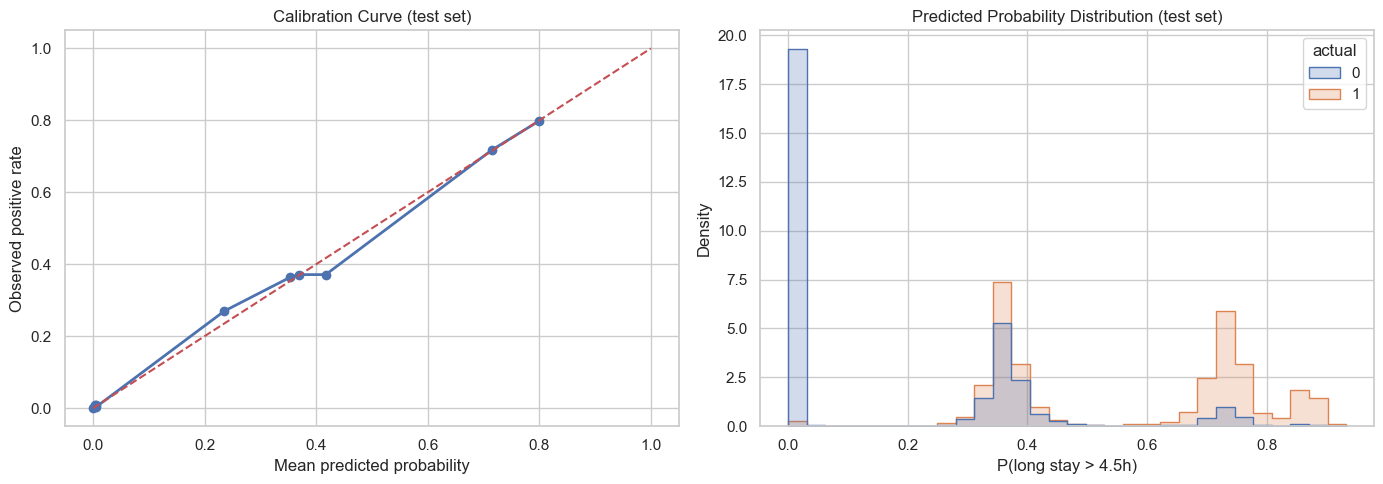

In [46]:
test_diagnostics_df = pd.DataFrame({
    "actual": y_test_classification.values,
    "predicted": test_predictions_classification,
    "pred_proba": test_proba,
})
test_diagnostics_df["prob_error"] = test_diagnostics_df["pred_proba"] - test_diagnostics_df["actual"]

# 1) Calibration by probability deciles (held-out test set)
test_diagnostics_df["pred_proba_decile"] = pd.qcut(
    test_diagnostics_df["pred_proba"],
    q=10,
    duplicates="drop"
).astype(str)

calibration_table = test_diagnostics_df.groupby("pred_proba_decile", observed=False).agg(
    n=("actual", "size"),
    actual_rate=("actual", "mean"),
    predicted_mean=("pred_proba", "mean"),
    mean_abs_error=("prob_error", lambda s: np.abs(s).mean())
).reset_index()

print("Calibration by predicted probability decile (test set)")
display(calibration_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

frac_pos, mean_pred = calibration_curve(test_diagnostics_df["actual"], test_diagnostics_df["pred_proba"], n_bins=10, strategy="quantile")
axes[0].plot(mean_pred, frac_pos, marker="o", linewidth=2)
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5)
axes[0].set_title("Calibration Curve (test set)")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed positive rate")

sns.histplot(data=test_diagnostics_df, x="pred_proba", hue="actual", bins=30, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Predicted Probability Distribution (test set)")
axes[1].set_xlabel("P(long stay > 4.5h)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

Threshold sensitivity on validation set (Youden threshold row marked)


,threshold,accuracy,precision,recall,f1,selected
0,0.1,0.718750,0.508987,0.995712,0.673629,False
1,0.2,0.718750,0.508987,0.995712,0.673629,True
2,0.3,0.721250,0.511348,0.985420,0.673308,True
3,0.4,0.806500,0.701854,0.584477,0.637810,False
4,0.5,0.816250,0.762485,0.536878,0.630096,False
5,0.6,0.815750,0.765470,0.530446,0.626646,False
6,0.7,0.803750,0.766434,0.469983,0.582669,False
7,0.8,0.738500,0.861446,0.122642,0.214715,False
8,0.9,0.709625,0.846154,0.004717,0.009382,False



Held-out test ROC-AUC: 0.870
Most common complaint tokens among misclassified test cases


,token,count
0,worsening,352
1,moderate,320
2,fever,272
3,vomiting,205
4,onset,203
5,acute,186
6,over,176
7,hours,176
8,known,159
9,since,156


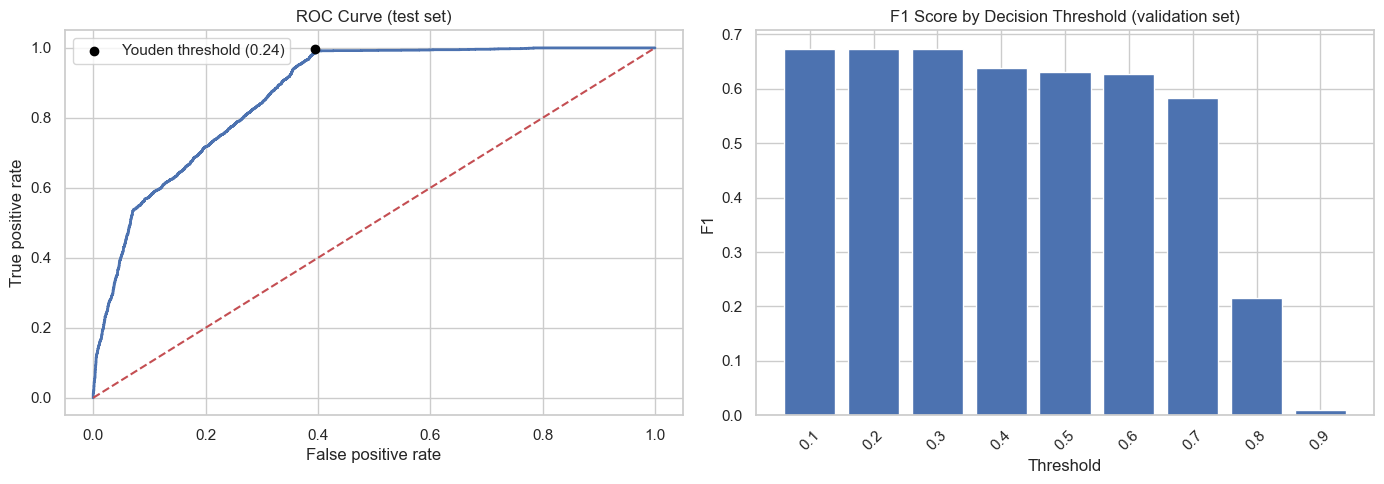

In [ ]:
from collections import Counter

# Threshold sensitivity on validation set (the set used for selection)
val_threshold_rows = []
for threshold in np.linspace(0.1, 0.9, 9):
    val_pred_t = (val_proba >= threshold).astype(int)
    val_threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "accuracy":  accuracy_score(y_val_classification, val_pred_t),
        "precision": precision_score(y_val_classification, val_pred_t, zero_division=0),
        "recall":    recall_score(y_val_classification, val_pred_t, zero_division=0),
        "f1":        f1_score(y_val_classification, val_pred_t, zero_division=0),
        "selected":  abs(threshold - prediction_threshold) < 0.06,
    })

threshold_table = pd.DataFrame(val_threshold_rows)
print("Threshold sensitivity on validation set (Youden threshold row marked)")
display(threshold_table)

# --- ROC curve on held-out test set ---
fpr_test, tpr_test, _ = roc_curve(y_test_classification, test_proba)
best_fpr = float(fpr_val[best_idx])
best_tpr = float(tpr_val[best_idx])

print(f"\nHeld-out test ROC-AUC: {roc_auc_score(y_test_classification, test_proba):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr_test, tpr_test, linewidth=2)
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5)
axes[0].scatter(best_fpr, best_tpr, color="black", zorder=3, label=f"Youden threshold ({prediction_threshold:.2f})")
axes[0].legend()
axes[0].set_title("ROC Curve (test set)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")

if "chief_complaint_raw" in X_test_classification.columns:
    token_source = X_test_classification.copy()
    correct = (test_predictions_classification == y_test_classification.values)
    token_source["correct"] = correct
    worst_cases = token_source.loc[~token_source["correct"], "chief_complaint_raw"].fillna("").astype(str).str.lower()
    tokens = worst_cases.str.findall(r"[a-z]{3,}").explode()
    stopwords = {
        "and", "for", "with", "from", "that", "this", "have", "been", "were", "into",
        "patient", "pain", "the", "she", "his", "her", "you", "not", "but", "are", "was", "had", "has"
    }
    tokens = tokens[(tokens.notna()) & (~tokens.isin(stopwords))]
    token_counts = Counter(tokens.tolist())
    top_tokens_df = pd.DataFrame(token_counts.most_common(10), columns=["token", "count"])
    print("Most common complaint tokens among misclassified test cases")
    display(top_tokens_df)
else:
    print("chief_complaint_raw not present in X_test_classification, skipping token analysis.")

axes[1].bar(threshold_table["threshold"].astype(str), threshold_table["f1"])
axes[1].set_title("F1 Score by Decision Threshold (validation set)")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Summary and Clinical Interpretation

### What has been built

This notebook demonstrates two complementary triage-time predictors of ED length of stay, trained on 80,000 visits and evaluated on an 8,000-patient held-out test set that was never touched during model development or threshold selection:

| Model | Key metrics | Practical meaning |
|---|---|---|
| **Regression** (exact hours) | MAE = 1.14 h, R² = 0.58 | Average prediction is within ~1 hour of actual LOS |
| **Classification** (long stay > 4.5 h) | Sensitivity 99.1%, Specificity 60.1%, ROC-AUC 0.87 | 99 of every 100 genuine long stays are detected at triage; 40% of true short stays are over-flagged |

Both models use only information available at triage — vital signs, chief complaint text, medical history, arrival context, and prior utilisation. No laboratory or imaging results are required.

---

### Classification model: reading the trade-off

The Youden threshold of **0.241** places the model at an extreme point on the precision-recall curve: very high recall at the cost of moderate specificity.

- Of **2,331 true long-stay patients** on the test set, **2,310 (99.1%)** were correctly flagged and only **21 (0.9%)** were missed.
- Of **5,669 true short-stay patients**, **3,406 (60.1%)** were correctly cleared and **2,263 (39.9%)** received unnecessary alerts.

This operating point is appropriate for bed-management scenarios where missing a long stay — a patient boarding without a plan — is the primary concern. Departments where nurse alert fatigue is prevalent may prefer a threshold of 0.40+, accepting a recall drop to ~58% in exchange for a precision increase from 51% to 70%.

---

### Strengths

- **Early**: predictions are available the moment triage documentation is complete, before any investigations are ordered
- **Explainable**: SHAP analysis shows exactly which triage features drove each individual prediction
- **Calibrated**: probability scores are well-calibrated at both extremes, supporting threshold reasoning based on clinical cost-benefit
- **Clinically informed**: engineered features (qSOFA, NEWS2 tier, shock index, organ-system burden) mirror the compound reasoning an experienced triage nurse applies

---

### Limitations and when not to trust the model

1. **Chief-complaint anchoring** — the model over-weights the primary complaint text. Cases annotated with minimising terms ("superficial," "uncomplicated," "mild") receive very low probabilities even when contextual flags (police arrival, confusion, secondary symptoms) suggest real complexity. Four of the five worst false negatives fall into this category.
2. **Rare severe presentations** — the regression model consistently underestimates LOS for catastrophic presentations. For acuity 1 patients, treat predictions as lower bounds.
3. **Investigation-driven holds** — patients held for cardiac monitoring, orthopaedic assessment, or neurology review are systematically underestimated because the diagnostic pathway is unknowable at triage.
4. **System and staffing changes** — the model was trained on historical patterns. If a department changes capacity, staffing models, or triage protocols, the model should be retrained.
5. **Population shift** — predictions may be less accurate for presentations not well represented in the training data.

---

### Recommended use cases

| Use case | Recommended output |
|---|---|
| Real-time bed alert dashboard | Classification probability score + flag at threshold 0.241 (or 0.40 in low-alert-fatigue departments) |
| Nurse handover prioritisation | Regression predicted hours, sorted descending |
| Shift-level workload forecast | Sum of predicted LOS across all current patients |
| Fast-track routing (discharge vs admit) | Classification flag (0 = fast-track eligible) |

The model is a **decision-support tool**, not a replacement for clinical judgment. Any patient whom a clinician assesses as more complex than the model suggests should be managed according to clinical assessment.

## Understanding the Decision Thresholds

This pipeline has two independent thresholds, one that defines the prediction task and one
that converts a probability into a yes/no decision.

---

### 1. The 4.5-hour clinical cutoff

The label `los_long_over_4_5h = 1` means the patient stayed **more than 4.5 hours**. This
cutoff is clinically meaningful for two reasons:

- **Operational:** Many health-system targets aim for non-admitted patients to be discharged
  within 4 hours. Patients above 4.5 h are clearly in a different care trajectory and will
  occupy a full ED bed, likely requiring investigation results, specialist review, or
  admission planning.
- **Statistical:** The dataset's 75th percentile LOS is ~4.86 h, making 4.5 h a natural
  boundary between the two populations (short-stay fast-track vs. complex stay).

---

### 2. The 0.241 decision threshold (Youden's J)

The model outputs a **probability** of long stay. To flag a patient, this probability is compared to the decision threshold, which was selected on the validation set by **maximising Youden's J statistic** (sensitivity + specificity − 1), then applied once to the held-out test set.

The threshold sensitivity analysis reveals a highly non-linear operating curve:

| Threshold | Recall | Specificity | Precision | F1 | When to use |
|---|---|---|---|---|---|
| **0.10 – 0.30** | ~99% | ~60% | ~51% | ~0.67 | Near-complete long-stay capture; highest false-alert rate |
| **0.241** *(chosen)* | 99.1% | 60.1% | 50.5% | 0.67 | Youden's J optimum; bed management where any miss is costly |
| **0.40** | 58.4% | 91.8% | 70.2% | 0.64 | Reduces false alerts substantially, but misses ~42% of long stays |
| **0.50** | 53.7% | 93.9% | 76.2% | 0.63 | Balanced; use when alert fatigue is a significant concern |
| **0.70+** | < 13% | > 98% | 77–85% | < 0.58 | Precision-focused; only flags near-certain long stays |

**Why 0.241 was chosen:** Youden's J selects the threshold that simultaneously maximises sensitivity and specificity. On this dataset, that operating point falls in a **flat high-recall plateau** where thresholds 0.10 through ~0.34 produce nearly identical recall and F1. There is no meaningful gain from fine-tuning within this range, the practical decision is whether to stay below 0.35 (≥98% recall) or jump above 0.40 (58% recall, 70% precision).

**The cliff at 0.4:** The sharp drop in recall between 0.30 and 0.40 reflects the model's bimodal probability distribution. Most predictions fall either near zero (clear short stays) or above 0.34 (likely long stays), with very few cases predicted in the 0.007–0.34 range. There is no gradual middle ground — the cliff is structural, not a tuning artefact.

**Key metrics:** ROC-AUC (0.870) measures overall discrimination regardless of threshold. PR-AUC (0.709) measures discrimination on the positive class only. Neither is affected by the chosen threshold.

## Feature Explanations (SHAP Analysis)

SHAP (SHapley Additive exPlanations) attributes the model's probability score to individual
features for each patient. Unlike simple feature importance, SHAP shows both *which* features
matter and *in which direction* they push each prediction. Values are computed on a 500-patient
sample from the held-out test set — the same patients whose outcomes were never seen during
training or threshold selection.

**How to read the beeswarm plot:**
- Each **dot** is one patient from the 500-patient test sample.
- **Colour**: red = **high value** for that feature; blue = low value.
- **Dots to the right** → the feature increased the model's estimate of P(long stay > 4.5 h).
- **Dots to the left** → the feature decreased that probability.
- Features are ordered by total impact across all patients (top = most influential).

**Interpreting in the context of the bimodal distribution:** Because the model assigns most
predictions either very low or moderately high probabilities, SHAP values for individual
features will often show clear clusters rather than smooth gradients — reflecting a model
that is highly confident about the majority of cases and uncertain mainly about the borderline
presentations seen in the misclassification review above.

SHAP computed for 500 held-out test patients.


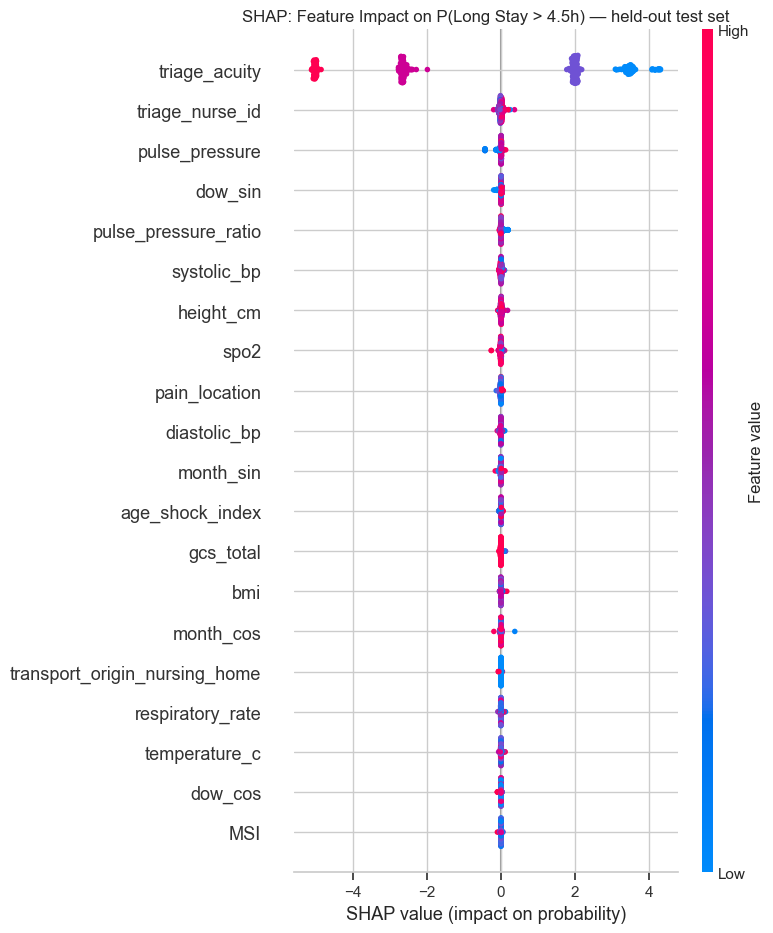

In [44]:
import shap

# 1. Extract components from the classification pipeline
inner_preprocessor = classification_model.named_steps['preprocess']
inner_classifier = classification_model.named_steps['classifier']

# 2. Prepare sample from held-out test set
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test_classification), size=min(500, len(X_test_classification)), replace=False)
X_sample = X_test_classification.iloc[sample_idx]
X_transformed = inner_preprocessor.transform(X_sample)

# 3. Get Feature Names dynamically from preprocessor
feature_names = []
for name, trans, cols in inner_preprocessor.transformers_:
    if name == 'remainder' or trans == 'drop':
        continue

    # Special handling for text branch because FunctionTransformer lacks get_feature_names_out
    if name == 'chief_complaint_text':
        try:
            # Navigate: Pipeline -> FeatureUnion -> Pipeline -> TfidfVectorizer
            tfidf = trans.named_steps['features'].transformer_list[0][1].named_steps['tfidf']
            feature_names.extend([f"CC_{w}" for w in tfidf.get_feature_names_out()])
        except:
            # Fallback if the structure differs
            current_count = X_transformed.shape[1] - len(feature_names)
            feature_names.extend([f"text_feat_{i}" for i in range(current_count)])
    elif name == 'time_cyc':
        feature_names.extend(['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos'])
    elif hasattr(trans, 'get_feature_names_out'):
        # Handles Ordinal, OneHot, and TargetEncoders
        names = trans.get_feature_names_out(cols)
        feature_names.extend(names)
    else:
        feature_names.extend(cols)

# Clean up prefixes for readability
feature_names = [n.replace('ord__', '').replace('nom__', '').replace('target__', '').replace('num__', '') for n in feature_names]

# 4. Compute SHAP values for the classifier
explainer = shap.TreeExplainer(inner_classifier)
shap_values = explainer.shap_values(X_transformed)

print(f'SHAP computed for {len(X_sample)} held-out test patients.')

# 5. Plot
plt.figure(figsize=(10, 8))
# For binary classification, we use the SHAP values for the positive class (long stay)
shap.summary_plot(
    shap_values[..., 1] if len(shap_values.shape) > 2 else shap_values,
    X_transformed,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP: Feature Impact on P(Long Stay > 4.5h) — held-out test set')
plt.xlabel('SHAP value (impact on probability)')
plt.tight_layout()
plt.show()